# SPF Model: Quantifying a Framework for Evaluating NBA Prospect Potential

This notebook implements and validates the **SPF (Skill, Physicality, Feel)** model — a framework for evaluating NBA draft prospects using publicly available college basketball statistics.

## What This Is
A quantitative test of the premise that NBA potential stems from three foundational pillars:
- **Skill** — for the purposes of this exercise, the ability to score efficiently and protect the ball
- **Physicality** — size, strength, length, and applied athletic tools
- **Feel** — the ability to process, move within, and manipulate the spacing and tempo of the game

The model scores prospects on each pillar and penalizes deficits in any of the three, on the basis that structural holes in a player's profile significantly limit their ceiling.

## What This Is Not
- A big board. The model has no opinions on positional value, archetype scarcity, or versatility.
- A machine learning model. There is no target variable. The goal is to quantitatively validate a framework, not to optimise prediction.

At its best, this model functions as a **companion to film-based evaluation** — surfacing players worth a closer look and flagging profiles with structural weaknesses.

---
*Data from [Bart Torvik](https://barttorvik.com), NBA combine records, and Dunks & Threes's EPM. Inspired by Layne Vashro's work on prospect improvement curves and age.*

## Setup

In [1]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from rapidfuzz import fuzz, process
from scipy import stats
from scipy.stats import norm
from scipy.stats.mstats import gmean
from sklearn.linear_model import LinearRegression
from sqlalchemy import create_engine, text

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 1. Data & Preprocessing

### 1.1 CBB Player Data

College player statistics are sourced from Bart Torvik's database, which provides per-possession stats, role classifications, and adjusted efficiency metrics for all NCAA players.

Data is loaded from CSV exports below. The original SQL queries used to extract from my underlying database are preserved in comments for reference.

In [2]:
# ── Data loading ──────────────────────────────────────────────────────────────
all_players = pd.read_csv("data/all_players.csv")

print(f"Loaded {len(all_players):,} player-season records")

Loaded 44,559 player-season records


### 1.2 Role Assignment

Bart Torvik's role classifications are mapped to five broader positional buckets — **Big, Forward, Wing, Off-ball G, On-ball G** — to increase sample sizes within each peer group and align more closely with how positions are discussed in draft evaluation.

Each player is assigned both a primary and secondary role. The data is melted on these two role assignments so that each player-season appears in both their primary and secondary peer pools during z-score computation. This ensures a wing-forward tweener, for example, can be evaluated against both wing and forward distributions.

In [3]:
# Map granular Bart roles to broader positional buckets
primary_conditions = [
    all_players['role'] == 'C',
    all_players['role'] == 'PF/C',
    all_players['role'] == 'Stretch 4',
    all_players['role'] == 'Wing F',
    all_players['role'] == 'Wing G',
    all_players['role'] == 'Combo G',
    all_players['role'] == 'Pure PG',
    all_players['role'] == 'Scoring PG',
]
primary_values = ['Big', 'Forward', 'Forward', 'Wing', 'Wing', 'Off-ball G', 'On-ball G', 'On-ball G']

secondary_conditions = [
    all_players['role'] == 'C',
    all_players['role'] == 'PF/C',
    all_players['role'] == 'Stretch 4',
    all_players['role'] == 'Wing F',
    all_players['role'] == 'Wing G',
    all_players['role'] == 'Combo G',
    all_players['role'] == 'Pure PG',
    all_players['role'] == 'Scoring PG',
]
secondary_values = ['Big', 'Big', 'Big', 'Forward', 'Off-ball G', 'On-ball G', 'On-ball G', 'On-ball G']

all_players['primary_role']   = np.select(primary_conditions,   primary_values,   default=np.nan)
all_players['secondary_role'] = np.select(secondary_conditions, secondary_values, default=np.nan)

# class_rank = 1 is the player's most recent season (pre-draft year)
all_players['class_rank'] = all_players.groupby('player_name')['year'].rank(
    method='min', ascending=False
)

# Melt so each player-season has one row per role assignment
melted = all_players.melt(
    id_vars=[c for c in all_players.columns if c not in ['primary_role', 'secondary_role']],
    value_vars=['primary_role', 'secondary_role'],
    var_name='role_type',
    value_name='role_bucket',
)
melted = melted.drop_duplicates(subset=['player_id', 'year', 'role_bucket'])
melted = melted.rename(columns={'year': 'season', 'yr': 'class_yr'})

print(f"Melted dataset: {len(melted):,} player-season-role rows")

Melted dataset: 77,402 player-season-role rows


### 1.3 Age & Strength of Schedule Adjustments

Two adjustment factors are pre-computed here and applied during composite construction.

**Strength of Schedule (SOS):** A player's statistics in a weak conference are less predictive of NBA performance than equivalent statistics against stronger competition. The SOS factor is the ratio of a team's actual defensive rating to their adjusted defensive rating (`drtg / adrtg`), applied to all performance metrics. This was the most applicable method I could find given the data available and accounted for the games in which a prospect did and did not appear.

**Age:** Younger players producing equivalent statistics to older players have more developmental runway ahead of them. Following [Vashro's research](https://www.canishoopus.com/2014/2/26/5435374/potential-nba-draft-prospects) on which statistical traits improve over time, age adjustments are applied selectively:

| Adjusted | Not Adjusted |
|----------|-------------|
| `ast_per`, `ft_per`, `two_per`, `adj_non_to_per` | `stl_per`, `blk_per`, `dr_per`, `or_per` |

Steal rate is not adjusted because research indicates feel and energy stats do not systematically improve with age — an older player's steal rate reflects a stable trait, not accumulated development.

The initial age adjustment uses the formula `0.95 ^ (age − 18)` and is applied at the **z-score level** (before percentile conversion), preserving sign so that older players are not inadvertently boosted on their weak metrics. The intent here is to dampen what olders players accomplished against younger players. A 22-year old posting the same assist rate as an 18-year old is not equivalent from an evaluation perspective.

In [4]:
melted['sos_adj'] = melted['drtg'] / melted['adrtg']
melted['age_adj']  = 0.9 ** (melted['age'] - 18)

### 1.4 Anthropometric Data

Height (without shoes), wingspan, and weight are sourced from NBA combine records and player bios, then merged onto the college dataset via a three-tier fuzzy matching strategy:

1. **Draft pick exact match** — if a player's draft pick number links unambiguously to a combine record (name similarity ≥ 70), use that match
2. **High-confidence name match** — fuzzy name matching against both college and NBA name fields, with school as a tiebreaker
3. **No match** — player is retained in the dataset without anthropometric data; potential physicality score will be dependent on listed college height

In [5]:
nba_bios = pd.read_csv("data/nba_bios.csv")

anthros = pd.read_csv("data/wingspan_all_2026-04-18.csv")
anthros = anthros.merge(nba_bios, how='left', left_on='nba_id', right_on='PlayerID')
anthros = anthros[['nba_id', 'player', 'DISPLAY_FIRST_LAST',
                   'height_wo_shoes_in', 'wingspan_in', 'SCHOOL', 'WEIGHT',
                   'DRAFT_NUMBER', 'BIRTHDATE']]

In [6]:
def normalize_name(name):
    """Lowercase, strip punctuation and suffixes for fuzzy matching."""
    if pd.isna(name):
        return ''
    name = name.lower().strip()
    name = re.sub(r"['\.\,\-]", '', name)
    name = re.sub(r'\b(jr|sr|ii|iii|iv)\b', '', name)
    return re.sub(r'\s+', ' ', name).strip()

def normalize_school(name):
    if pd.isna(name):
        return ''
    name = name.lower().strip()
    name = re.sub(r'[^\w\s]', '', name)
    return re.sub(r'\s+', ' ', name).strip()

melted['name_normalized']   = melted['player_name'].apply(normalize_name)
melted['team_normalized']   = melted['team'].apply(normalize_school)
anthros['name_normalized_cbb'] = anthros['player'].apply(normalize_name)
anthros['name_normalized_nba'] = anthros['DISPLAY_FIRST_LAST'].apply(normalize_name)
anthros['school_normalized']   = anthros['SCHOOL'].apply(normalize_school)

def fuzzy_join(left, right, name_threshold=90):
    """
    Three-tier matching strategy:
      1. Draft pick exact match + name plausibility check
      2. High-confidence fuzzy name match, school as tiebreaker
      3. Drop unmatched rows
    """
    results      = []
    right_names_cbb = right['name_normalized_cbb'].tolist()
    right_names_nba = right['name_normalized_nba'].tolist()
    draft_lookup    = right[right['DRAFT_NUMBER'].notna()].set_index('DRAFT_NUMBER')

    for _, left_row in left.iterrows():
        left_name = left_row['name_normalized']
        left_team = left_row['team_normalized']
        left_pick = left_row.get('draft_pick')

        # Tier 1: draft pick exact match
        if pd.notna(left_pick) and left_pick in draft_lookup.index:
            right_row  = draft_lookup.loc[left_pick]
            name_score = max(
                fuzz.token_sort_ratio(left_name, right_row['name_normalized_cbb']),
                fuzz.token_sort_ratio(left_name, right_row['name_normalized_nba']),
            )
            if name_score >= 70:
                results.append({
                    **left_row.to_dict(), **right_row.to_dict(),
                    'match_name_score': name_score, 'match_school_score': None,
                    'match_combined_score': 100, 'match_type': 'draft_pick_exact',
                })
                continue

        # Tier 2: fuzzy name match
        candidates_cbb = process.extract(left_name, right_names_cbb,
                                         scorer=fuzz.token_sort_ratio,
                                         limit=5, score_cutoff=name_threshold)
        candidates_nba = process.extract(left_name, right_names_nba,
                                         scorer=fuzz.token_sort_ratio,
                                         limit=5, score_cutoff=name_threshold)

        candidate_map = {}
        for _, score, idx in candidates_cbb + candidates_nba:
            if idx not in candidate_map or score > candidate_map[idx]:
                candidate_map[idx] = score

        if not candidate_map:
            continue

        best_match, best_combined, best_name_score, best_school_score = None, 0, 0, 0
        for idx, name_score in candidate_map.items():
            right_row    = right.iloc[idx]
            school_score = fuzz.token_sort_ratio(left_team, right_row['school_normalized'])
            combined     = name_score * 0.7 + school_score * 0.3
            if combined > best_combined:
                best_combined, best_name_score, best_school_score, best_match = (
                    combined, name_score, school_score, right_row
                )

        if best_combined >= 90:
            results.append({
                **left_row.to_dict(), **best_match.to_dict(),
                'match_name_score': best_name_score, 'match_school_score': best_school_score,
                'match_combined_score': best_combined,
                'match_type': 'exact' if best_name_score == 100 else 'fuzzy',
            })

    return pd.DataFrame(results)

joined = fuzzy_join(melted, anthros)
print(joined['match_type'].value_counts())
print(f"Confident matches: {len(joined):,} of {len(melted):,} player-season-role rows")

match_type
exact    2868
fuzzy       5
Name: count, dtype: int64
Confident matches: 2,873 of 77,402 player-season-role rows


In [7]:
# Merge anthropometrics back onto main dataset
melted = melted.merge(
    joined[['player_id', 'nba_id', 'height_wo_shoes_in', 'wingspan_in', 'WEIGHT', 'BIRTHDATE']],
    on='player_id', how='left',
)

combine = pd.read_csv("data/combine.csv")

melted = melted.merge(combine[['player_id', 'weight']], on='player_id', how='left')
melted['weight_cleaned'] = melted['weight'].fillna(melted['WEIGHT'])
melted['weight_cleaned'] = melted['weight_cleaned'].replace('', np.nan).astype('float')

# 2026 prospect measurements (pre-combine reports and combine results)
measure = pd.read_csv("data/2026_prospect_measurements.csv")
melted  = melted.merge(measure, how='left', left_on='player_name', right_on='player')

# Fill measurement gaps in priority order: combine > prospect report > Bart height
melted['height_wo_shoes_in'] = (melted['height_wo_shoes_in']
                                .fillna(melted['combine_height'])
                                .fillna(melted['inches'] - 1.5))
melted['wingspan_in']   = melted['wingspan_in'].fillna(melted['combine_ws'])
melted['weight_cleaned'] = melted['weight_cleaned'].fillna(melted['combine_weight'])

### 1.5 Feature Engineering

In [8]:
# Derived metrics
melted['adj_non_to_per']        = 100 - melted['adj_to_per']   # turnover avoidance rate
melted['bmi']                   = (melted['weight_cleaned'] / (melted['height_wo_shoes_in'] ** 2)) * 703
melted['wingspan_height_ratio'] = melted['wingspan_in'] / melted['height_wo_shoes_in']
melted.drop_duplicates(inplace=True)

print(f"Final dataset: {len(melted):,} rows | {melted['player_name'].nunique():,} unique players")

Final dataset: 77,408 rows | 19,341 unique players


## 2. Model Construction

### 2.1 Z-Score Computation

Each metric is z-scored against a **positional peer pool** to make performance comparable across roles and eras.

- **Performance metrics** (`ast_per`, `ft_per`, `two_per`, etc.) use a **3-season rolling window** — the player's role group across the current and two preceding seasons. This provides sufficient sample size while keeping the comparison group relevant and capturing changes in the game.
- **Anthropometric metrics** (`height`, `wingspan`, `bmi`) use a **cumulative pool** of all seasons up to and including the current one, since physical measurements don't evolve with the basketball calendar.

A minimum pool of **10 players** is required to compute z-scores; flagged rows are excluded from composite calculations. The age adjustment is applied to developmental metrics at this stage: `adj_z = sign(z) × |z| × age_adj`, which preserves sign so that older players are not inadvertently boosted on their weak metrics.

In [9]:
METRICS = [
    'ft_per', 'ast_per', 'adj_non_to_per',            # skill / feel
    'stl_per', 'blk_per', 'dr_per', 'or_per',         # physicality / feel
    'two_per',                                        # skill
    'height_wo_shoes_in', 'wingspan_in',              # potential physicality
    'bmi', 'wingspan_height_ratio',                   # potential physicality
]

ANTHRO_METRICS = ['height_wo_shoes_in', 'wingspan_in', 'bmi', 'wingspan_height_ratio']

# Age adjustment applies only to developable skill/feel metrics
AGE_ADJUSTED_METRICS = ['ast_per', 'ft_per', 'two_per', 'adj_non_to_per']

for col in ANTHRO_METRICS:
    melted[col] = melted[col].astype(float)

def calculate_zscores(df, metrics=METRICS):
    """
    Compute z-scores for each metric against a positional peer pool.
    Anthropometric metrics use a cumulative pool; performance metrics use a 3-year window.
    Age adjustment is applied to developable metrics at the z-score level before percentiling.
    """
    df      = df.copy()
    pool_df = df.copy()

    for metric in metrics:
        is_anthro = metric in ANTHRO_METRICS
        df[f'{metric}_zscore'] = np.nan
        df[f'{metric}_low_n']  = False

        for (season_val, role_val), group_idx in df.groupby(['season', 'role_bucket']).groups.items():
            if is_anthro:
                pool = pool_df[
                    (pool_df['season'] <= season_val) &
                    (pool_df['role_bucket'] == role_val) &
                    (pool_df['role_type'] == 'primary_role')
                ][metric].dropna()
            else:
                pool = pool_df[
                    (pool_df['season'].isin([season_val, season_val - 1, season_val - 2])) &
                    (pool_df['role_bucket'] == role_val) &
                    (pool_df['role_type'] == 'primary_role')
                ][metric].dropna()

            n = len(pool)
            if n < 10:
                df.loc[group_idx, f'{metric}_low_n'] = True
                continue

            mean, std = pool.mean(), pool.std()
            if std > 0:
                raw_z = (df.loc[group_idx, metric] - mean) / std

                if metric in AGE_ADJUSTED_METRICS:
                    # Apply age adjustment preserving sign: older players are dampened
                    # but not flipped — a poor facilitator stays a poor facilitator
                    age_adj = df.loc[group_idx, 'age_adj']
                    sos_adj = df.loc[group_idx, 'sos_adj']
                    raw_z   = np.sign(raw_z) * np.abs(raw_z) * age_adj
                    raw_z   = np.sign(raw_z) * np.abs(raw_z) * sos_adj

                df.loc[group_idx, f'{metric}_zscore'] = raw_z
            df.loc[group_idx, f'{metric}_low_n'] = n < 20

    return df

primary_zscores = calculate_zscores(melted[melted['role_type'] == 'primary_role'])
all_zscores     = calculate_zscores(melted)
print("Z-scores computed.")

Z-scores computed.


### 2.2 Pillar Composites

Z-scores are converted to percentiles via the normal CDF, then aggregated into pillar scores using a **power mean with p=2**. This formulation tilts toward rewarding outlier abilities rather than pure consistency — capturing the bankable skills that earn players playing time at the next level, and avoiding over-rewarding jack-of-all-trades-master-of-none profiles.

| Pillar | Metrics | Adjustments |
|--------|---------|-------------|
| **Skill** | `two_per`, `ft_per`, `adj_non_to_per` | Age + SOS |
| **Feel** | `ast_per`, `stl_per` | Age (`ast_per` only) + SOS |
| **Applied Physicality** | `blk_per`, `dr_per`, `or_per` | SOS only |
| **Potential Physicality** | `height`, `wingspan`, `bmi` | None |

Applied and potential physicality are combined via **geometric mean** to form the physicality composite. The three pillar composites are then combined via geometric mean to produce the **SPF Composite** — the primary model output. The geometric mean penalizes pillar deficits: a player with a very low feel score will see their overall composite pulled down even if skill and physicality are strong.

A second age adjustment is applied to the composite score with the intent of adjusting for where on the development curve a player sits. A 22-year old player's development curve looks different than an 18-year old's. This second age adjustment accounts for that.

In [10]:
def repercentile_pillars(df):
    """
    Re-percentile pillar scores against the primary role distribution only.
    Secondary role players are scored relative to where they fall in the
    distribution of players who primarily play that role — preserving the
    original intent of the secondary role comparison.
    """
    has_role_type = 'role_type' in df.columns

    for col in ['feel_composite', 'skill_composite', 'physicality_composite']:
        df[f'{col}_pctile'] = np.nan

        for role in df['role_bucket'].dropna().unique():
            # Reference pool: primary role players only
            if has_role_type:
                ref_pool = df[
                    (df['role_bucket'] == role) &
                    (df['role_type'] == 'primary_role')
                ][col].dropna().values
            else:
                ref_pool = df[df['role_bucket'] == role][col].dropna().values

            if len(ref_pool) == 0:
                continue

            # Assign percentiles to all players in this role (primary + secondary)
            role_mask = (df['role_bucket'] == role) & df[col].notna()
            values    = df.loc[role_mask, col].values

            # Vectorized: for each value, fraction of primary pool it exceeds
            pctiles = (values[:, None] > ref_pool[None, :]).mean(axis=1) * 100
            df.loc[role_mask, f'{col}_pctile'] = pctiles

    return df

In [11]:
def power_mean(values, p):
    """Power mean with exponent p. p=2 rewards outlier abilities over consistency."""
    values = values[~np.isnan(values)]
    return np.power(np.mean(np.power(values, p)), 1 / p) if len(values) > 0 else np.nan

def nan_gmean(values):
    """Geometric mean ignoring NaNs. Penalises pillar deficits at composite level."""
    values = values[~np.isnan(values)]
    return gmean(values) if len(values) > 0 else np.nan

def build_composites(df):
    """
    Convert z-scores to percentiles and aggregate into pillar and composite scores.
    """
    zscore_cols = [
        'ft_per_zscore', 'stl_per_zscore', 'blk_per_zscore', 'two_per_zscore',
        'dr_per_zscore', 'or_per_zscore', 'height_wo_shoes_in_zscore',
        'wingspan_in_zscore', 'bmi_zscore', 'ast_per_zscore',
        'adj_non_to_per_zscore', 'wingspan_height_ratio_zscore',
    ]
    for col in zscore_cols:
        pct_col        = col.replace('_zscore', '_pct')
        df[pct_col]    = norm.cdf(df[col]) * 100
        df[pct_col]    = df[pct_col].clip(0.1, 99.9)

    # ── Pillar scores ──────────────────────────────────────────────────────────
    df['feel_composite'] = (
        df[['ast_per_pct', 'stl_per_pct']]
        .apply(lambda r: power_mean(r.values, p=2), axis=1)
    )
    df['applied_physicality_composite'] = (
        df[['blk_per_pct', 'dr_per_pct', 'or_per_pct']]
        .apply(lambda r: power_mean(r.values, p=2), axis=1)
    )
    df['potential_physicality_composite'] = (
        df[['height_wo_shoes_in_pct', 'wingspan_in_pct', 'bmi_pct']]
        .apply(lambda r: power_mean(r.values, p=2), axis=1)
    )
    df['skill_composite'] = (
        df[['ft_per_pct', 'two_per_pct', 'adj_non_to_per_pct']]
        .apply(lambda r: power_mean(r.values, p=2), axis=1)
    )

    # ── Physicality composite: gmean of applied + potential ───────────────────
    df['physicality_composite'] = (
        df[['applied_physicality_composite', 'potential_physicality_composite']]
        .apply(lambda r: nan_gmean(r.values), axis=1)
    )

    df = repercentile_pillars(df)
    
    # ── Pillar intersections and SPF composite ────────────────────────────────
    df['fs_intersection'] = df[['feel_composite_pctile', 'skill_composite_pctile']]\
        .apply(lambda r: nan_gmean(r.values), axis=1)
    df['fp_intersection'] = df[['feel_composite_pctile', 'physicality_composite_pctile']]\
        .apply(lambda r: nan_gmean(r.values), axis=1)
    df['ps_intersection'] = df[['physicality_composite_pctile', 'skill_composite_pctile']]\
        .apply(lambda r: nan_gmean(r.values), axis=1)
    df['fps_composite']   = df[['feel_composite_pctile', 'skill_composite_pctile', 'physicality_composite_pctile']]\
        .apply(lambda r: nan_gmean(r.values), axis=1)

    df['fps_composite'] = df['fps_composite'] * (0.95 ** (melted['age'] - 18))
    
    return df

primary_zscores = build_composites(primary_zscores)
all_zscores     = build_composites(all_zscores)
print("Composites built.")

Composites built.


### 2.3 Pillar Independence Check

A useful model requires that the three pillars capture meaningfully distinct aspects of a player's profile. High correlation between pillars would indicate redundancy — that knowing one score largely tells you the others — which would undermine the framework's premise that deficits in *any* pillar are independently limiting.

The heatmaps below show within-role pillar correlations. Perfect independence is not achievable (many on-court events reflect multiple pillars simultaneously), but the goal is to minimize redundancy through metric assignment.

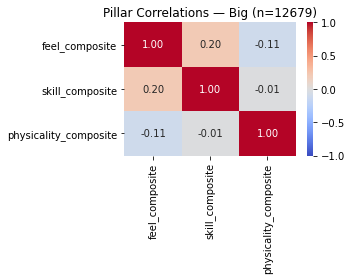

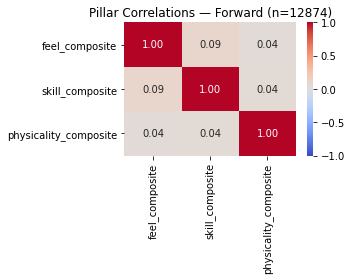

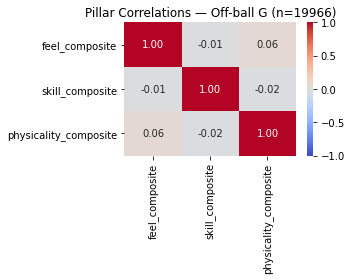

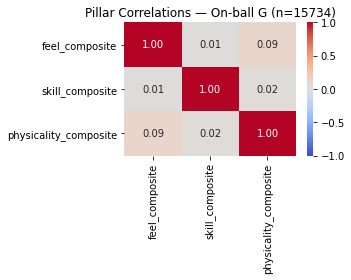

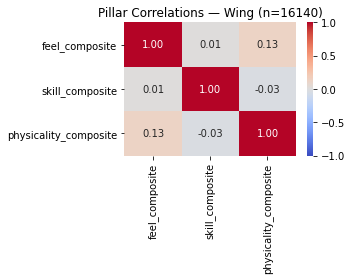

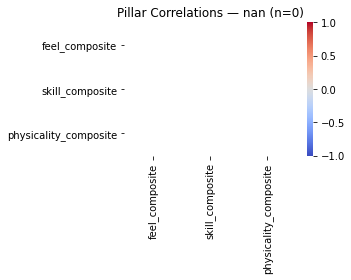

In [12]:
for role in sorted(all_zscores['role_bucket'].dropna().unique()):
    role_df = all_zscores[all_zscores['role_bucket'] == role][
        ['feel_composite', 'skill_composite', 'physicality_composite']
    ].dropna()
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(role_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f'Pillar Correlations — {role} (n={len(role_df)})')
    plt.tight_layout()
    plt.show()

## 3. Findings

### 3.1 Outcome Data

Outcomes are measured using the peak Dunks & Threes's EPM (Estimated Plus-Minus) recorded over a player's **rookie contract** — the first four seasons, the period over which a team must make their initial decision on a player's future.

Players are classified into four outcome tiers based on their **peak season EPM** within this window:

| Tier | EPM Threshold |
|------|--------------|
| **Star** | ≥ 3.0 |
| **Starter** | 1.0 – 3.0 |
| **Rotation** | −1.0 – 1.0 |
| **Bust** | < −1.0 |

For visualization, players are bucketed within their positional role group as **Low** (≤ 40th percentile), **Mid** (40th–80th percentile), or **High** (≥ 80th percentile) on each composite score.

In [13]:
epm = pd.read_csv("data/epm.csv")

# Merge model scores with outcomes — restrict to player's pre-draft season
all_time = (
    primary_zscores[primary_zscores['age'] > 0][
        ['player_name', 'team', 'season', 'draft_pick', 'conference', 'role_bucket',
         'skill_composite_pctile', 'physicality_composite_pctile', 'feel_composite_pctile',
         'fp_intersection', 'ps_intersection', 'fs_intersection',
         'fps_composite', 'age', 'nba_id', 'class_rank']
    ]
    .query("class_rank == 1 and season < 2024")
)

model = all_time.merge(epm, how='inner', left_on='nba_id', right_on='player_id')

# Assign Low / Mid / High buckets within each role group
composites = {
    'skill_bucket': 'skill_composite_pctile', 'feel_bucket': 'feel_composite_pctile',
    'physicality_bucket': 'physicality_composite_pctile', 'ps_bucket': 'ps_intersection',
    'fs_bucket': 'fs_intersection',    'fp_bucket': 'fp_intersection',
    'fps_bucket': 'fps_composite',
}

for bucket_col, composite_col in composites.items():
    q40 = model.groupby('role_bucket')[composite_col].transform(lambda x: x.quantile(0.40))
    q80 = model.groupby('role_bucket')[composite_col].transform(lambda x: x.quantile(0.80))
    
    model[bucket_col] = np.select(
        [model[composite_col] < q40, model[composite_col] < q80],
        ['Low', 'Mid'],
        default='High'
    )

print(f"Validation dataset: {len(model):,} players with both SPF scores and EPM outcomes")
print(model['fps_bucket'].value_counts())

Validation dataset: 654 players with both SPF scores and EPM outcomes
fps_bucket
Low     262
Mid     260
High    132
Name: count, dtype: int64


### 3.2 Outcome Distributions by Pillar

The charts below show how outcomes vary across the Low / Mid / High tiers of each individual pillar score, broken down by positional role. If the framework is valid, higher pillar scores should consistently correlate with better outcomes — and deficits should cap upside.

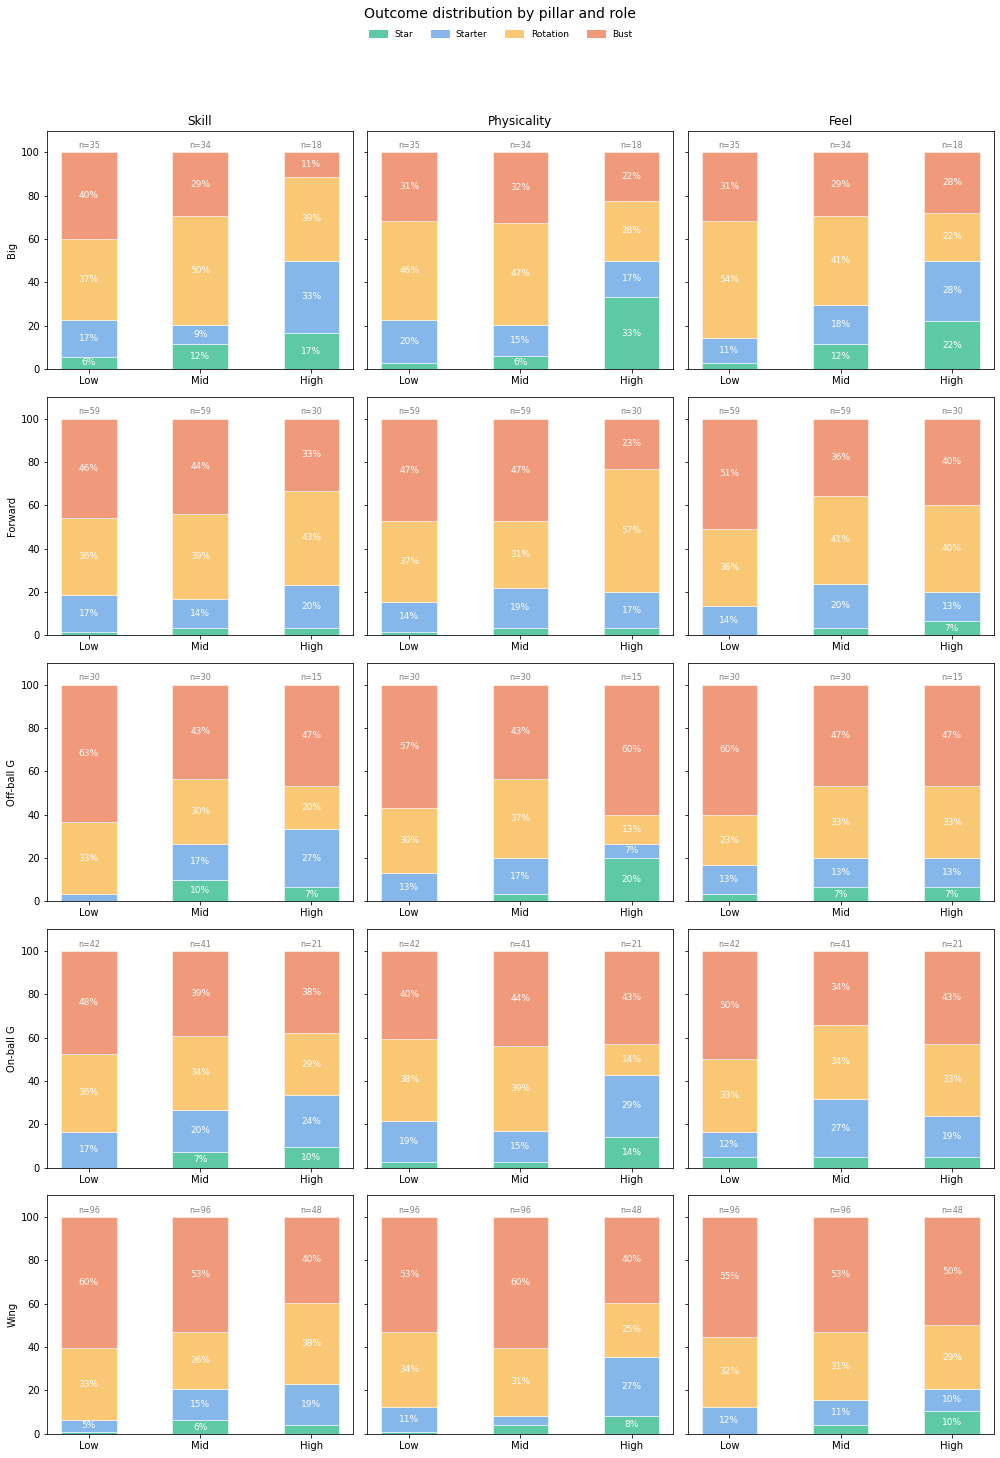

In [14]:
outcomes       = ['star_ind', 'starter_ind', 'rotation_ind', 'bust_ind']
outcome_labels = ['Star', 'Starter', 'Rotation', 'Bust']
outcome_colors = ['#5DCAA5', '#85B7EB', '#FAC775', '#F0997B']
bucket_order   = ['Low', 'Mid', 'High']
roles          = sorted(model['role_bucket'].dropna().unique())

def plot_outcome_distributions(model, pillars, pillar_labels, title, filename):
    n_roles = len(roles)
    fig, axes = plt.subplots(n_roles, len(pillars), figsize=(14, 4 * n_roles), sharey=True)
    fig.suptitle(title, fontsize=14, fontweight='500', y=1.01)

    legend_elements = [plt.Rectangle((0, 0), 1, 1, color=c, label=l)
                       for c, l in zip(outcome_colors, outcome_labels)]
    fig.legend(handles=legend_elements, loc='upper center',
               bbox_to_anchor=(0.5, 1.0), ncol=4, fontsize=9, frameon=False)

    for row, role in enumerate(roles):
        for col, (pillar, label) in enumerate(zip(pillars, pillar_labels)):
            ax        = axes[row][col]
            plot_data = model[(model[pillar].notna()) & (model['role_bucket'] == role)]
            props_list, ns = [], []

            for bucket in bucket_order:
                bdf = plot_data[plot_data[pillar] == bucket]
                ns.append(len(bdf))
                props_list.append([
                    bdf[o].sum() / len(bdf) * 100 if len(bdf) > 0 else 0
                    for o in outcomes
                ])

            proportions = np.array(props_list)
            bottoms     = np.zeros(len(bucket_order))

            for i, (o, lbl, color) in enumerate(zip(outcomes, outcome_labels, outcome_colors)):
                bars = ax.bar(bucket_order, proportions[:, i], bottom=bottoms,
                              color=color, width=0.5, edgecolor='white', linewidth=0.5)
                for j, (bar, val) in enumerate(zip(bars, proportions[:, i])):
                    if val > 5:
                        ax.text(bar.get_x() + bar.get_width() / 2, bottoms[j] + val / 2,
                                f'{val:.0f}%', ha='center', va='center',
                                fontsize=9, color='white', fontweight='500')
                bottoms += proportions[:, i]

            for i, (bucket, n) in enumerate(zip(bucket_order, ns)):
                ax.text(i, 102, f'n={n}', ha='center', fontsize=8, color='gray')

            if col == 0:
                ax.set_ylabel(role, fontsize=10, fontweight='500')
            if row == 0:
                ax.set_title(label)
            ax.set_ylim(0, 110)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_outcome_distributions(
    model,
    pillars=['skill_bucket', 'physicality_bucket', 'feel_bucket'],
    pillar_labels=['Skill', 'Physicality', 'Feel'],
    title='Outcome distribution by pillar and role',
    filename='output/outcome_by_pillar_and_role.png',
)

### 3.3 Outcome Distributions by Pillar Intersection

Beyond individual pillars, the model computes pairwise intersection scores — the geometric mean of two pillar composites. These capture players who show complementary strengths across two dimensions simultaneously, which the framework suggests is a stronger predictor of high-end outcomes than strength in any single pillar alone.

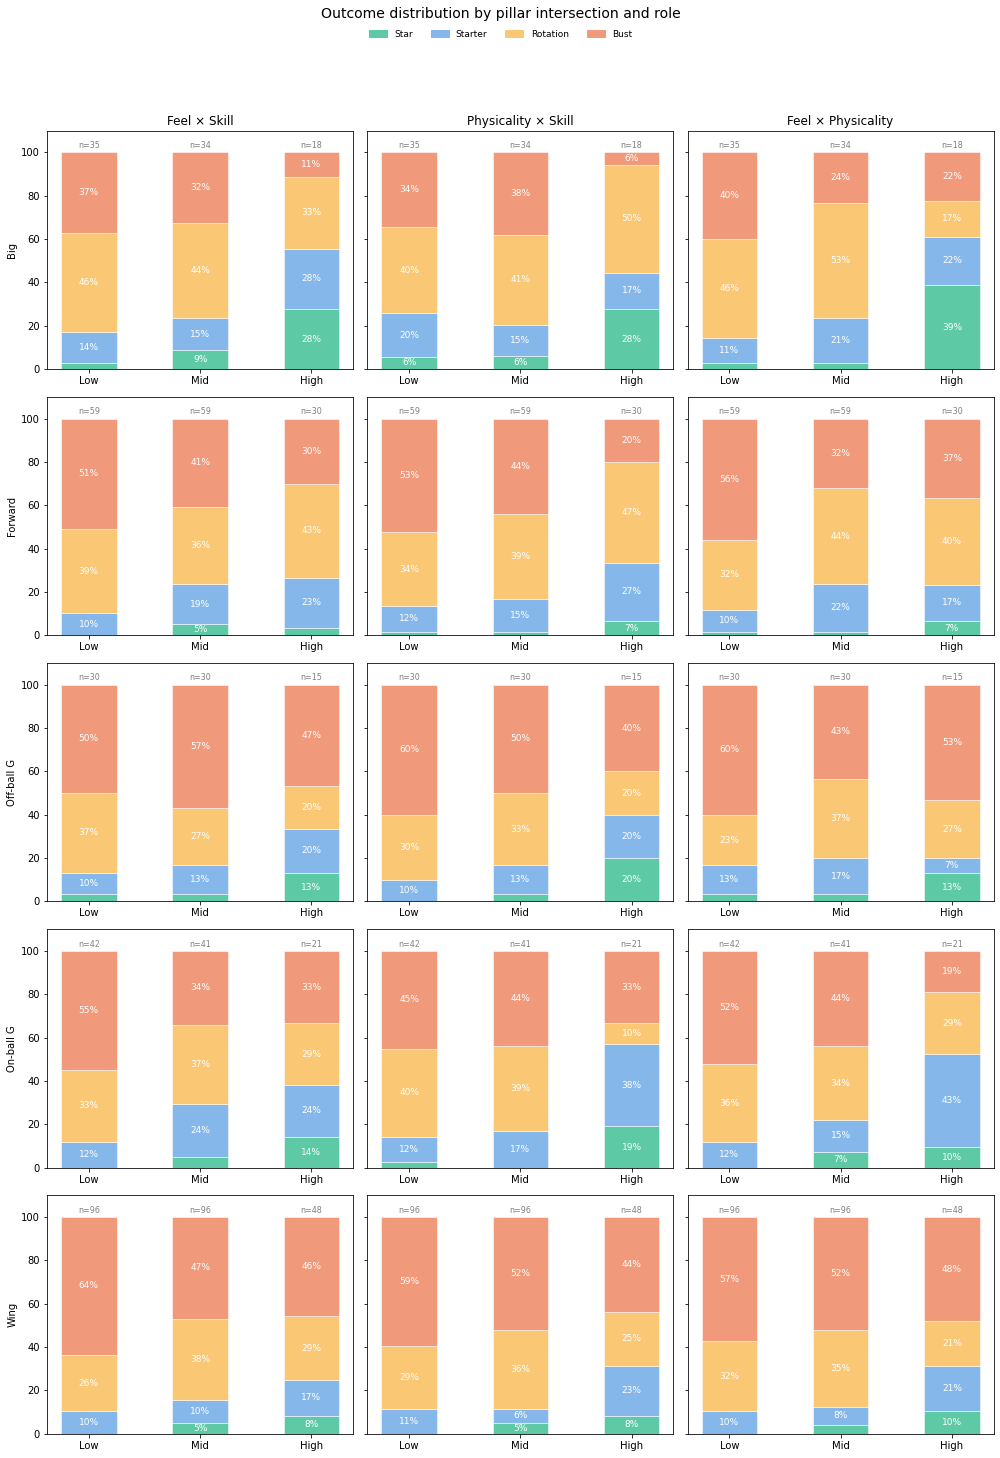

In [15]:
plot_outcome_distributions(
    model,
    pillars=['fs_bucket', 'ps_bucket', 'fp_bucket'],
    pillar_labels=['Feel × Skill', 'Physicality × Skill', 'Feel × Physicality'],
    title='Outcome distribution by pillar intersection and role',
    filename='output/outcome_by_pillar_intersection_and_role.png',
)

### 3.4 SPF Composite Results

The SPF Composite is the primary model output — the geometric mean of all three pillar scores. Players scoring in the **top 20% (High tier)** within their role group disproportionately produce star and starter outcomes on their rookie contracts. Players in the **bottom 40% (Low tier)** very rarely develop into starters.

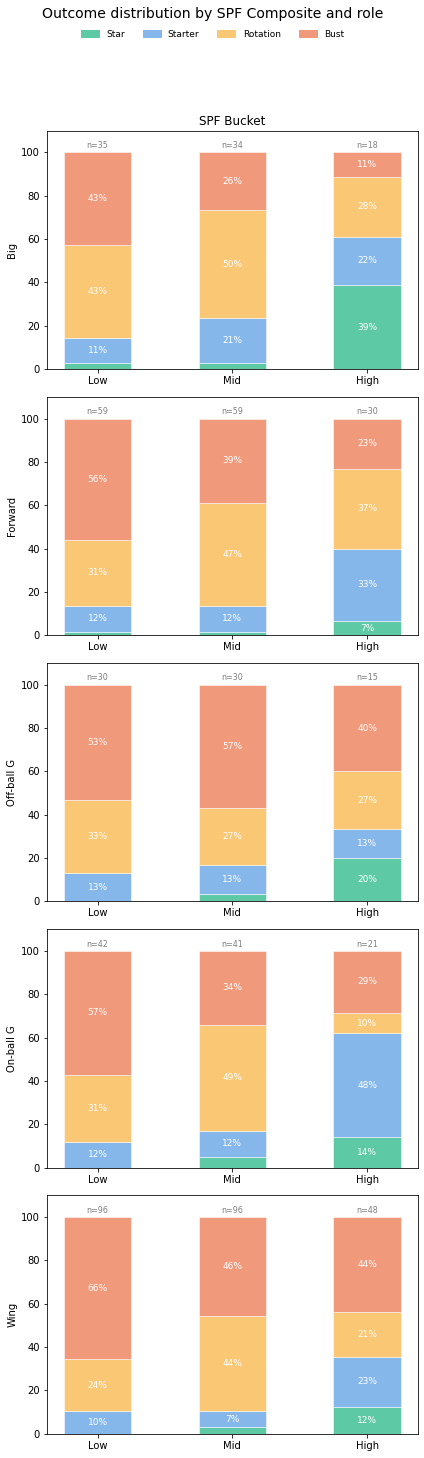

In [16]:
# Composite outcome distributions by role
n_roles = len(roles)
fig, axes = plt.subplots(n_roles, 1, figsize=(6, 4 * n_roles), sharey=True)
fig.suptitle('Outcome distribution by SPF Composite and role',
             fontsize=14, fontweight='500', y=1.01)

legend_elements = [plt.Rectangle((0, 0), 1, 1, color=c, label=l)
                   for c, l in zip(outcome_colors, outcome_labels)]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 1.0), ncol=4, fontsize=9, frameon=False)

for row, role in enumerate(roles):
    ax        = axes[row]
    plot_data = model[(model['fps_bucket'].notna()) & (model['role_bucket'] == role)]
    props_list, ns = [], []

    for bucket in bucket_order:
        bdf = plot_data[plot_data['fps_bucket'] == bucket]
        ns.append(len(bdf))
        props_list.append([bdf[o].sum() / len(bdf) * 100 if len(bdf) > 0 else 0 for o in outcomes])

    proportions = np.array(props_list)
    bottoms     = np.zeros(len(bucket_order))

    for i, (o, lbl, color) in enumerate(zip(outcomes, outcome_labels, outcome_colors)):
        bars = ax.bar(bucket_order, proportions[:, i], bottom=bottoms,
                      color=color, width=0.5, edgecolor='white', linewidth=0.5)
        for j, (bar, val) in enumerate(zip(bars, proportions[:, i])):
            if val > 5:
                ax.text(bar.get_x() + bar.get_width() / 2, bottoms[j] + val / 2,
                        f'{val:.0f}%', ha='center', va='center',
                        fontsize=9, color='white', fontweight='500')
        bottoms += proportions[:, i]

    for i, (bucket, n) in enumerate(zip(bucket_order, ns)):
        ax.text(i, 102, f'n={n}', ha='center', fontsize=8, color='gray')
    ax.set_ylabel(role, fontsize=10, fontweight='500')
    if row == 0:
        ax.set_title('SPF Bucket')
    ax.set_ylim(0, 110)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('output/outcome_by_spf_composite_and_role.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Star and starter rate summary by SPF tier
summary_rows = []
for bucket, label in [('Low', '≤ 40th percentile'), ('Mid', '40th–80th'), ('High', '≥ 80th percentile')]:
    bdf = model[model['fps_bucket'] == bucket]
    n   = len(bdf)
    summary_rows.append({
        'SPF Tier': f'{bucket} ({label})',
        'N Players': n,
        'Star %':    f"{bdf['star_ind'].mean() * 100:.0f}%",
        'Starter %': f"{(bdf['star_ind'].sum() + bdf['starter_ind'].sum()) / n * 100:.0f}%",
        'Bust %':    f"{bdf['bust_ind'].mean() * 100:.0f}%",
    })

pd.DataFrame(summary_rows).set_index('SPF Tier')

,N Players,Star %,Starter %,Bust %
SPF Tier,,,,
Low (≤ 40th percentile),262,1%,12%,58%
Mid (40th–80th),260,3%,15%,41%
High (≥ 80th percentile),132,16%,44%,32%


## 4. Validation

### 4.1 Methodology

Two complementary approaches test whether the SPF composite adds genuine predictive value beyond what is already captured in draft consensus.

**Pairwise Concordance**

For every pair of players, we ask: does the player with the higher SPF score also have the better NBA outcome (measured by average EPM wins)? 

`Concordance = concordant pairs / (concordant + discordant pairs)`

A random model produces 0.50. Tied pairs (identical score or outcome) are excluded. Bootstrap confidence intervals (1,000 resamples at the player level) quantify uncertainty; a one-sided binomial test assesses statistical significance against the null of 0.50.

**Orthogonal Signal Test**

Draft position already aggregates substantial scouting information. The more interesting question is whether SPF explains outcome variance *beyond* what draft position captures:

1. **Residual concordance** — Regress `avg_wins` on `draft_pick`; measure concordance of the SPF score against the residuals. A result consistently above 0.50 means SPF sees something the market missed.
2. **Combined model lift** — Standardize both SPF and draft position, average into a combined score, measure concordance. Positive lift over draft position alone indicates additive, independent signal.

All tests are restricted to **drafted players with outcomes through the 2023 season**.

In [18]:
def pairwise_concordance(scores: np.ndarray, outcomes: np.ndarray) -> dict:
    """
    Vectorised pairwise concordance between a score array and an outcome array.
    Concordance = concordant / (concordant + discordant); tied pairs excluded.
    A random model produces ~0.50.
    """
    mask             = ~np.isnan(scores) & ~np.isnan(outcomes)
    scores, outcomes = scores[mask], outcomes[mask]
    n                = len(scores)

    if n < 2:
        return dict(concordance=np.nan, n_concordant=0,
                    n_discordant=0, n_ties=0, n_pairs=0, n_players=n)

    i_idx, j_idx  = np.triu_indices(n, k=1)
    score_diffs   = scores[i_idx]   - scores[j_idx]
    outcome_diffs = outcomes[i_idx] - outcomes[j_idx]

    tied       = (score_diffs == 0) | (outcome_diffs == 0)
    concordant = int(np.sum((np.sign(score_diffs) == np.sign(outcome_diffs)) & ~tied))
    discordant = int(np.sum((np.sign(score_diffs) != np.sign(outcome_diffs)) & ~tied))
    n_ties     = int(np.sum(tied))
    usable     = concordant + discordant

    return dict(
        n_players=n, n_concordant=concordant, n_discordant=discordant,
        n_ties=n_ties, n_pairs=usable + n_ties,
        concordance=concordant / usable if usable > 0 else np.nan,
    )


def binomial_pvalue(n_concordant: int, n_discordant: int) -> float:
    """One-sided binomial test: H0 = concordance ≤ 0.50."""
    n = n_concordant + n_discordant
    return stats.binomtest(n_concordant, n, p=0.5, alternative='greater').pvalue if n > 0 else np.nan


def bootstrap_ci(scores, outcomes, n_bootstrap=1000, ci=0.95, seed=42):
    rng  = np.random.default_rng(seed)
    mask = ~np.isnan(scores) & ~np.isnan(outcomes)
    s, o = scores[mask], outcomes[mask]
    n    = len(s)

    boot = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)          # single index applied to both
        c   = pairwise_concordance(s[idx], o[idx])['concordance']
        if not np.isnan(c):
            boot.append(c)

    alpha = 1 - ci
    return (
        float(np.percentile(boot, 100 * alpha / 2)),
        float(np.percentile(boot, 100 * (1 - alpha / 2))),
    )

def _sig_stars(p):
    if np.isnan(p): return ''
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    return ''


SCORE_COLS  = ['skill_composite', 'physicality_composite', 'feel_composite',
               'fp_intersection', 'ps_intersection', 'fs_intersection', 'fps_composite']
OUTCOME_COL = 'avg_wins'

def run_concordance_analysis(df, outcome_col=OUTCOME_COL, score_cols=SCORE_COLS,
                              within_role=True, role_col='role_bucket',
                              include_draft_baseline=True, n_bootstrap=1000):
    """
    Concordance analysis for all score columns vs. the outcome, overall and per role.
    Draft pick (inverted) is included as a naive benchmark.
    """
    df = df.copy()
    cols = list(score_cols)
    if include_draft_baseline and 'draft_pick' in df.columns:
        df['draft_pick_inv'] = -df['draft_pick']
        cols.append('draft_pick_inv')

    rows = []
    def _evaluate(subset, role_label):
        for col in cols:
            if col not in subset.columns:
                continue
            s   = subset[col].values.astype(float)
            o   = subset[outcome_col].values.astype(float)
            res = pairwise_concordance(s, o)
            p   = binomial_pvalue(res['n_concordant'], res['n_discordant'])
            lo, hi = bootstrap_ci(s, o, n_bootstrap=n_bootstrap)
            rows.append({
                'role': role_label, 'score_col': col,
                'n_players': res['n_players'], 'n_pairs': res['n_pairs'],
                'concordance': round(res['concordance'], 4) if not np.isnan(res['concordance']) else np.nan,
                'ci_low': round(lo, 4), 'ci_high': round(hi, 4),
                'p_value': round(p, 4) if not np.isnan(p) else np.nan,
                'sig': _sig_stars(p),
            })

    _evaluate(df, 'Overall')
    if within_role and role_col in df.columns:
        for role, group in df.groupby(role_col):
            _evaluate(group, role)

    return pd.DataFrame(rows).sort_values(['role', 'concordance'], ascending=[True, False])

### 4.2 Concordance vs. Draft Baseline

In [19]:
concordance_model = model[
    (model['draft_pick'] > 0) & (model['season'] < 2024)
].copy()

results = run_concordance_analysis(concordance_model, n_bootstrap=1000)

print("── Overall Pillar Concordance ──────────────────────────────")
overall = results[results['role'] == 'Overall'].sort_values('concordance', ascending=False)
print(overall[['score_col', 'n_pairs', 'concordance', 'ci_low', 'ci_high', 'p_value', 'sig']]
      .to_string(index=False))

print("\n── SPF vs Draft Pick Baseline ──────────────────────────────")
baseline = results[
    (results['role'] == 'Overall') &
    (results['score_col'].isin(['fps_composite', 'draft_pick_inv']))
]
print(baseline[['score_col', 'concordance', 'ci_low', 'ci_high', 'p_value', 'sig']]
      .to_string(index=False))

── Overall Pillar Concordance ──────────────────────────────
      score_col  n_pairs  concordance  ci_low  ci_high  p_value sig
 draft_pick_inv   139128       0.6548  0.6300   0.6796      0.0 ***
  fps_composite   139128       0.6233  0.5959   0.6521      0.0 ***
ps_intersection   139128       0.6034  0.5756   0.6331      0.0 ***
fs_intersection   139128       0.5985  0.5720   0.6270      0.0 ***
fp_intersection   139128       0.5932  0.5646   0.6222      0.0 ***

── SPF vs Draft Pick Baseline ──────────────────────────────
     score_col  concordance  ci_low  ci_high  p_value sig
draft_pick_inv       0.6548  0.6300   0.6796      0.0 ***
 fps_composite       0.6233  0.5959   0.6521      0.0 ***


### 4.3 Orthogonal Signal Test

In [20]:
def orthogonal_signal_test(df, score_col='fps_composite', outcome_col='avg_wins',
                           draft_col='draft_pick', n_bootstrap=1000):
    """
    Tests whether score_col carries signal orthogonal to draft position.

    Approach 1 — Residual concordance:
        Regress outcome on draft_pick; measure concordance of score_col against
        residuals. Above 0.50 = SPF sees what the market missed.

    Approach 2 — Combined model lift:
        Average standardised draft position and SPF score; measure concordance.
        Positive lift over draft alone = independent additive signal.
    """
    df   = df.copy()
    mask = df[score_col].notna() & df[outcome_col].notna() & df[draft_col].notna()
    df   = df[mask].copy()

    # Approach 1: residual concordance
    reg = LinearRegression().fit(df[[draft_col]].values, df[outcome_col].values)
    df['outcome_residual'] = df[outcome_col].values - reg.predict(df[[draft_col]].values)
    res_c  = pairwise_concordance(df[score_col].values.astype(float),
                                  df['outcome_residual'].values.astype(float))
    res_ci = bootstrap_ci(df[score_col].values.astype(float),
                          df['outcome_residual'].values.astype(float), n_bootstrap)

    # Approach 2: combined model
    def zscore(s): return (s - s.mean()) / s.std()
    df['combined'] = (zscore(-df[draft_col].astype(float)) + zscore(df[score_col].astype(float))) / 2

    comb_c  = pairwise_concordance(df['combined'].values.astype(float), df[outcome_col].values.astype(float))
    comb_ci = bootstrap_ci(df['combined'].values.astype(float), df[outcome_col].values.astype(float), n_bootstrap)
    draf_c  = pairwise_concordance(-df[draft_col].values.astype(float), df[outcome_col].values.astype(float))
    draf_ci = bootstrap_ci(-df[draft_col].values.astype(float), df[outcome_col].values.astype(float), n_bootstrap)

    return {
        'n_players':            len(df),
        'residual_concordance': round(res_c['concordance'], 4),
        'residual_ci':          (round(res_ci[0], 4), round(res_ci[1], 4)),
        'residual_p':           round(binomial_pvalue(res_c['n_concordant'], res_c['n_discordant']), 4),
        'draft_concordance':    round(draf_c['concordance'], 4),
        'draft_ci':             (round(draf_ci[0], 4), round(draf_ci[1], 4)),
        'combined_concordance': round(comb_c['concordance'], 4),
        'combined_ci':          (round(comb_ci[0], 4), round(comb_ci[1], 4)),
        'combined_lift':        round(comb_c['concordance'] - draf_c['concordance'], 4),
    }

result = orthogonal_signal_test(concordance_model, score_col='fps_composite', n_bootstrap=1000)

print(f"── Orthogonal Signal Test: fps_composite ────────────────────")
print(f"  N players                  : {result['n_players']}")
print(f"\n  Approach 1 — Residual concordance")
print(f"  (above 0.50 = SPF sees what draft position missed)")
print(f"  Concordance vs residuals   : {result['residual_concordance']}")
print(f"  95% CI                     : {result['residual_ci']}")
print(f"  p-value                    : {result['residual_p']}")
print(f"\n  Approach 2 — Combined model lift")
print(f"  (positive lift = SPF contributing independent signal)")
print(f"  Draft pick alone           : {result['draft_concordance']}  {result['draft_ci']}")
print(f"  Draft + SPF combined       : {result['combined_concordance']}  {result['combined_ci']}")
print(f"  Lift from adding SPF       : {result['combined_lift']:+.4f}")

── Orthogonal Signal Test: fps_composite ────────────────────
  N players                  : 528

  Approach 1 — Residual concordance
  (above 0.50 = SPF sees what draft position missed)
  Concordance vs residuals   : 0.5673
  95% CI                     : (0.5375, 0.598)
  p-value                    : 0.0

  Approach 2 — Combined model lift
  (positive lift = SPF contributing independent signal)
  Draft pick alone           : 0.6548  (0.63, 0.6796)
  Draft + SPF combined       : 0.6657  (0.6415, 0.6923)
  Lift from adding SPF       : +0.0109


## 5. Limitations & Future Work

### Known Model Limitations

**Skill pillar overvalues play finishers.** The current skill metrics — two-point percentage, 
free throw percentage, and turnover avoidance — reward players who score efficiently within 
a system without capturing how much of that scoring is self-created or against set defenses. 
A play-finishing big and a self-creating guard can produce identical skill scores despite 
representing meaningfully different prospects. A future iteration would incorporate volume 
of self-created scoring and half-court versus transition efficiency splits.

**Feel pillar is narrowly defined.** Assist rate and steal rate are reasonable proxies for feel 
but produce a definition that skews toward on-ball players and misses feel as it manifests 
in bigs and off-ball players — positional awareness, screening intelligence, and defensive 
anticipation that doesn't register as a steal. This is partly a data availability problem; 
tracking data that would better capture these qualities isn't publicly available at the 
college level. As such, the model greatly undervalues clear high-feel players like Kon 
Knueppel, Jared McCain, and Morez Johnson whose feel manifests itself in their off-ball 
movement and understanding of space and leverage.

**Physicality pillar tilts towards strength over athleticism.** The model captures size, 
strength, and applied physical tools well but has no indicator of lateral agility or 
explosiveness. This creates known issues with tweener profiles — a 3/4 tweener may score well 
physically as a wing while lacking the athleticism to defend wings at the next level. Similarly, BMI
is considered a positive, but too much BMI is not a good thing when it comes to playing high-level
basketball


**Positional classification affects specific players.** Role assignments follow Bart Torvik's 
classifications, which occasionally misalign with how a player projects at the next level. 
Brandon Miller and Cooper Flagg are the most notable examples — classified as forwards 
rather than wings, their physicality scores are penalized against a forward peer pool despite 
projecting as a wings at the NBA level.

**Single season evaluation.** The primary model output uses a player's pre-draft season only. 
Analysis throughout this piece suggests that prior seasons contain meaningful signal, 
particularly for players who were heavily penalized by age and strength of schedule 
adjustments in their draft year.

### Validation Scope

The concordance analysis is conducted on drafted players from 2010 through 2023 with 
available EPM outcomes. Undrafted players are excluded from the primary validation, and 
outcome data becomes sparser for the most recent classes as players are still early in their 
careers. Results should be interpreted with those constraints in mind.

### Future Work

- Incorporate multi-season evaluation, weighting prior seasons to capture trajectory signal
- Add self-creation and half-court efficiency metrics to the skill pillar
- Explore lateral agility proxies for the physicality pillar
- Develop a positional portability score to better handle tweener archetypes
- Extend validation to undrafted players to test whether the model identifies value the 
  market missed entirely

---

Class big boards for all draft classes in the validation set are available 
[here]('https://docs.google.com/spreadsheets/d/1k9D0SUzhbhiBtCVeLGc3mii9nXjnSpd6rsh3FP96GJE/edit?gid=1412637268#gid=1412637268').